In [1]:
import pandas as pd

df = pd.read_csv('../../data/04_secom.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

빈칸비율 = df[sensor_cols].isna().mean() * 100
값종류수 = df[sensor_cols].nunique()
표준편차 = df[sensor_cols].std()

버릴_열 = 빈칸비율[빈칸비율 >= 50].index \
    .union(값종류수[값종류수 == 1].index) \
    .union(표준편차[표준편차 <= 0.001].index)

남길_열 = [c for c in sensor_cols if c not in 버릴_열]
df1 = df[['measured_at', 'result'] + 남길_열]

print('df 행/열 수:', df.shape)
print('df1 행/열 수:', df1.shape)

df 행/열 수: (1567, 592)
df1 행/열 수: (1567, 438)


# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


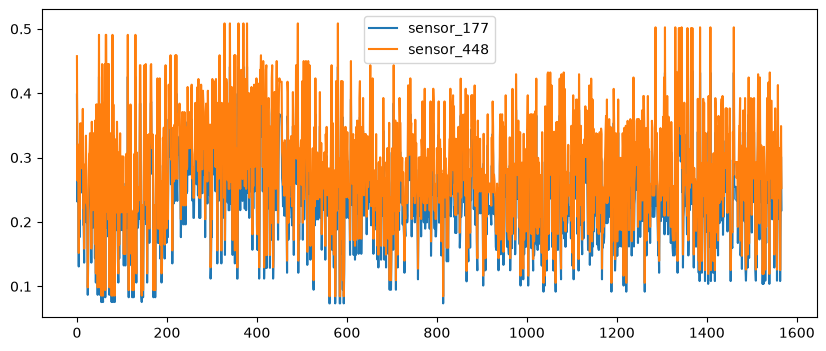

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()

## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 값을 "평균에서 표준편차 몇 배 떨어졌나"로 바꿔 적는 것. 단위가 다른 열을 같은 자로 재게 된다 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

In [3]:
# corr() - 두 열이 얼마나 같이 움직이는지 -1 ~ 1 사이 숫자로 계산한다
겹침정도 = df1[센서A].corr(df1[센서B])

print(센서A, "와", 센서B, "의 상관계수:", round(겹침정도, 4))

sensor_177 와 sensor_448 의 상관계수: 0.9999


### 문법 노트 - 열끼리 비교하기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| .corr(다른열) | 두 열의 상관계수를 계산 | 그림 없이 숫자 하나로 겹침 정도를 잰다 |
| .values | 표의 값만 꺼낸다 | 그래프를 그릴 때 줄 번호가 아니라 값만 필요해서 |
| plt.plot() | 값을 순서대로 선으로 잇는다 | 두 센서 모양을 겹쳐 보기 위해 |
| plt.legend() | 어느 선이 무엇인지 표시 | 선이 둘 이상이면 없으면 구분이 안 된다 |

**부호는 무시하고 크기만 본다.**<br>
-0.9 와 0.9 는 방향만 반대일 뿐 "강하게 붙어 다닌다"는 점에서 같다.<br>
그래서 겹치는 짝을 찾을 때는 절댓값을 쓴다.

## Step 3. 겹치는 짝 전부 찾아 대표만 남기기

In [4]:
import itertools

# df1의 센서 열끼리 상관계수를 전부 계산한다
sensor_cols1 = [c for c in df1.columns if c.startswith('sensor_')]
상관행렬 = df1[sensor_cols1].corr()

# 절댓값 0.9 이상인 짝을 전부 찾는다 (같은 짝을 두 번 세지 않도록 조합만 사용)
짝들 = []
cols = 상관행렬.columns
for i, j in itertools.combinations(range(len(cols)), 2):
    v = 상관행렬.iloc[i, j]
    if pd.notna(v) and abs(v) >= 0.9:
        짝들.append({'열1': cols[i], '열2': cols[j], '상관계수': v})

짝_표 = pd.DataFrame(짝들)
짝_표['절댓값'] = 짝_표['상관계수'].abs()

print('절댓값 0.9 이상인 짝 개수:', len(짝_표))
print('\n상위 10쌍 (절댓값 기준)')
display(짝_표.sort_values('절댓값', ascending=False).head(10)[['열1', '열2', '상관계수']])

절댓값 0.9 이상인 짝 개수: 342

상위 10쌍 (절댓값 기준)


,열1,열2,상관계수
23,sensor_075,sensor_210,1.0
26,sensor_075,sensor_479,1.0
25,sensor_075,sensor_348,1.0
24,sensor_075,sensor_343,1.0
285,sensor_343,sensor_348,1.0
176,sensor_210,sensor_348,1.0
177,sensor_210,sensor_479,1.0
166,sensor_207,sensor_210,1.0
175,sensor_210,sensor_343,1.0
168,sensor_207,sensor_348,1.0


In [5]:
# 겹치는 짝마다, 빈칸 비율이 더 적은 쪽을 남기고 나머지를 제거 대상에 넣는다
빈칸비율1 = df1[sensor_cols1].isna().mean()

제거할_열 = set()
for _, 행 in 짝_표.iterrows():
    a, b = 행['열1'], 행['열2']
    if 빈칸비율1[a] <= 빈칸비율1[b]:
        제거할_열.add(b)
    else:
        제거할_열.add(a)

# df와 df1은 그대로 두고, 새 이름 df2로 만든다
df2 = df1.drop(columns=list(제거할_열))

print('제거한 열 수:', len(제거할_열))
print('df1 열 수:', df1.shape[1])
print('df2 열 수:', df2.shape[1])

제거한 열 수: 190
df1 열 수: 438
df2 열 수: 248


[Step 3 결과]<br>
절댓값 0.9 이상인 짝 : [342]쌍<br>
짝마다 빈칸 비율이 더 적은 쪽만 남기고 제거한 열 : [190]개<br>
df1 열 수 : [438] → df2 열 수 : [248]<br>
df, df1은 그대로 두고 df2를 새로 만들었다

## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [6]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
sensor_001,3014.452896,73.621787,2743.2400,3356.3500
sensor_002,2495.850231,80.407705,2158.7500,2846.4400
sensor_003,2200.547318,29.513152,2060.6600,2315.2667
sensor_004,1396.376627,441.691640,0.0000,3715.0417
sensor_007,101.112908,6.237214,82.1311,129.2522
sensor_008,0.121822,0.008961,0.0000,0.1286
sensor_009,1.462862,0.073897,1.1910,1.6564
sensor_010,-0.000841,0.015116,-0.0534,0.0749
sensor_011,0.000146,0.009302,-0.0349,0.0530
sensor_012,0.964353,0.012452,0.6554,0.9848


In [7]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())

평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


값의 크기가 가장 다른 두 열: sensor_022 / sensor_091


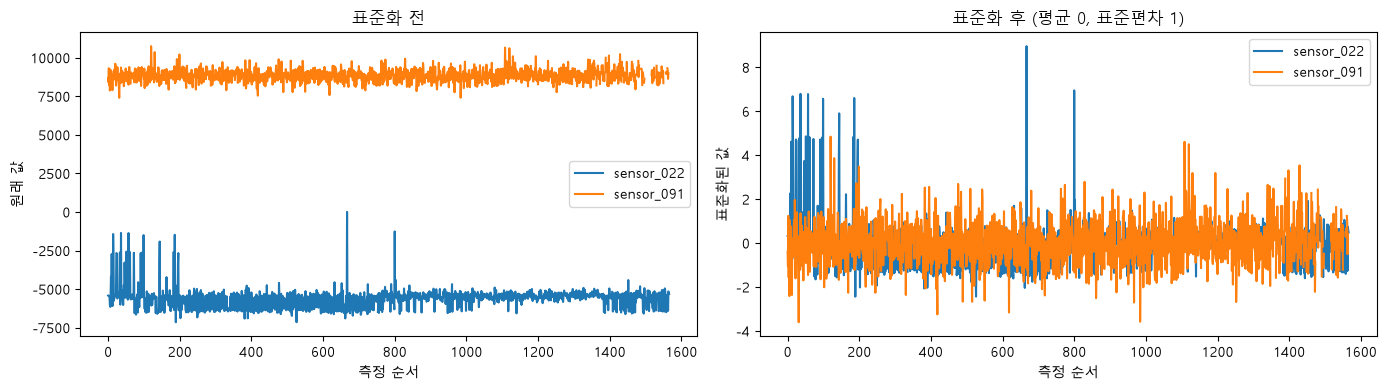

df2는 바뀌지 않았는지 확인 → sensor_022 평균: -5618.3936


In [8]:
import matplotlib.pyplot as plt

# 그래프에 한글이 네모(□)로 깨지지 않도록 한글 폰트 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 앞에서 구한, 평균이 가장 작은 열과 가장 큰 열 = 값의 크기가 가장 다른 두 열
열_작음 = 평균들.idxmin()
열_큼 = 평균들.idxmax()
print("값의 크기가 가장 다른 두 열:", 열_작음, "/", 열_큼)

# 표준화 — 평균 0, 표준편차 1이 되도록 바꾼다 (그림을 그리기 위한 계산일 뿐, df2는 그대로 둔다)
표준화_작음 = (df2[열_작음] - df2[열_작음].mean()) / df2[열_작음].std()
표준화_큼 = (df2[열_큼] - df2[열_큼].mean()) / df2[열_큼].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 표준화 전 — 두 열의 값 크기가 서로 크게 다른 그대로
axes[0].plot(df2[열_작음].values, label=열_작음)
axes[0].plot(df2[열_큼].values, label=열_큼)
axes[0].set_title("표준화 전")
axes[0].set_xlabel("측정 순서")
axes[0].set_ylabel("원래 값")
axes[0].legend()

# 표준화 후 — 평균 0, 표준편차 1 기준으로 맞춘 값
axes[1].plot(표준화_작음.values, label=열_작음)
axes[1].plot(표준화_큼.values, label=열_큼)
axes[1].set_title("표준화 후 (평균 0, 표준편차 1)")
axes[1].set_xlabel("측정 순서")
axes[1].set_ylabel("표준화된 값")
axes[1].legend()

fig.tight_layout()
plt.show()

print("df2는 바뀌지 않았는지 확인 →", 열_작음, "평균:", round(df2[열_작음].mean(), 4))

[Step 4 결과]<br>
값의 크기가 가장 다른 두 열 : [sensor_022] / [sensor_091]<br>
표준화 전 평균 : [-5618.39] / [8827.54]<br>
표준화(평균 0, 표준편차 1)로 맞추면 두 열이 같은 축 위에서 겹쳐 움직이는 것으로 보인다<br>
df2는 바뀌지 않았다 (표준화는 그림을 그리기 위한 계산일 뿐)

표준편차가 가장 큰 열 : sensor_163 → 6553.569317232143
표준편차가 가장 작은 열: sensor_144 → 0.00128180932587709
두 열의 크기 차이     : 5112749 배

                   mean          std  min         max
sensor_163  4797.154633  6553.569317  0.0  36871.0000
sensor_144     0.004169     0.001282  0.0      0.0121

[표준화 후] 평균과 표준편차
        sensor_163    sensor_144
mean -7.264335e-17 -4.469396e-16
std   1.000000e+00  1.000000e+00


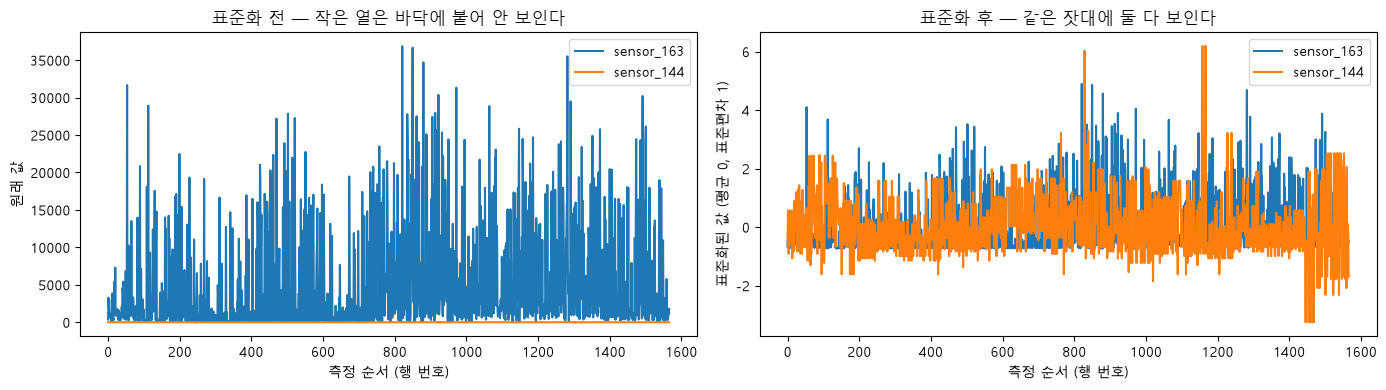

df2는 바뀌지 않았는지 확인 → sensor_163 표준편차: 6553.5693


In [9]:
import matplotlib.pyplot as plt

# 그래프에 한글이 네모(□)로 깨지지 않도록 한글 폰트 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# df2의 센서 열들의 표준편차를 모아서, 가장 큰 열과 가장 작은 열 = 값의 크기가 가장 다른 두 열
sensor_cols2 = [c for c in df2.columns if c.startswith('sensor_')]
표준편차들 = df2[sensor_cols2].std()

열_큼 = 표준편차들.idxmax()
열_작음 = 표준편차들.idxmin()

print("표준편차가 가장 큰 열 :", 열_큼, "→", 표준편차들.max())
print("표준편차가 가장 작은 열:", 열_작음, "→", 표준편차들.min())
print("두 열의 크기 차이     :", round(표준편차들.max() / 표준편차들.min()), "배")
print()
print(df2[[열_큼, 열_작음]].describe().T[["mean", "std", "min", "max"]])

# 표준화 — 평균 0, 표준편차 1이 되도록 바꾼다 (그림을 그리기 위한 계산일 뿐, df2는 그대로 둔다)
표준화_큼 = (df2[열_큼] - df2[열_큼].mean()) / df2[열_큼].std()
표준화_작음 = (df2[열_작음] - df2[열_작음].mean()) / df2[열_작음].std()

print()
print("[표준화 후] 평균과 표준편차")
print(pd.DataFrame(
    {열_큼: [표준화_큼.mean(), 표준화_큼.std()], 열_작음: [표준화_작음.mean(), 표준화_작음.std()]},
    index=["mean", "std"],
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 표준화 전 — 값의 크기가 워낙 달라서 작은 열은 거의 바닥에 붙어 안 보인다
axes[0].plot(df2[열_큼].values, label=열_큼)
axes[0].plot(df2[열_작음].values, label=열_작음)
axes[0].set_title("표준화 전 — 작은 열은 바닥에 붙어 안 보인다")
axes[0].set_xlabel("측정 순서 (행 번호)")
axes[0].set_ylabel("원래 값")
axes[0].legend()

# 표준화 후 — 평균 0, 표준편차 1 기준으로 맞추면 같은 잣대에서 둘 다 보인다
axes[1].plot(표준화_큼.values, label=열_큼)
axes[1].plot(표준화_작음.values, label=열_작음)
axes[1].set_title("표준화 후 — 같은 잣대에 둘 다 보인다")
axes[1].set_xlabel("측정 순서 (행 번호)")
axes[1].set_ylabel("표준화된 값 (평균 0, 표준편차 1)")
axes[1].legend()

fig.tight_layout()
plt.show()

print("df2는 바뀌지 않았는지 확인 →", 열_큼, "표준편차:", round(df2[열_큼].std(), 4))

## Step 5. 결과와 관련 있는 열부터 순서대로 보기

In [10]:
# result 열은 그대로 두고, 숫자로 바꾼 새 열 '불량여부'를 추가한다 (불량=1, 양품=0)
df2['불량여부'] = (df2['result'] == '불량').astype(int)

print(df2[['result', '불량여부']].head())

# df2의 센서 열 각각과 불량여부의 상관계수를 구한다
sensor_cols2 = [c for c in df2.columns if c.startswith('sensor_')]
상관 = df2[sensor_cols2].corrwith(df2['불량여부'])

# 절댓값 기준으로 정렬해서 상위 20개만 rank_table로 남긴다
rank_table = pd.DataFrame({
    '센서 이름': 상관.index,
    '상관계수 절댓값': 상관.abs().values,
}).sort_values('상관계수 절댓값', ascending=False).head(20).reset_index(drop=True)

rank_table

  result  불량여부
0     양품     0
1     양품     0
2     불량     1
3     양품     0
4     양품     0


C:\Users\13sx0\AppData\Local\Temp\ipykernel_23960\3799661646.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2['불량여부'] = (df2['result'] == '불량').astype(int)


,센서 이름,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_432,0.120851
4,sensor_431,0.110067
5,sensor_022,0.108488
6,sensor_029,0.107252
7,sensor_130,0.103373
8,sensor_211,0.102545
9,sensor_164,0.100330


[Step 5 결과]<br>
result는 그대로 두고, 숫자 열 '불량여부'(불량=1, 양품=0)를 새로 추가했다<br>
df2의 센서 열 [246]개 각각과 불량여부의 상관계수를 구했다<br>
상관계수 절댓값이 가장 큰 열 : [sensor_060] → [0.1558]<br>
상위 20개 모두 절댓값 [0.16] 미만 → 불량과 강하게 연결된 센서 하나는 없어 보인다<br>
정렬한 상위 20개 표는 [rank_table]이라는 이름으로 남겨두었다 (센서 이름, 상관계수 절댓값 두 열만)

In [11]:
# rank_table 1등 열 이름을 꺼낸다
일등_열 = rank_table.loc[0, '센서 이름']
print("rank_table 1등 열:", 일등_열)

# result가 양품인 행과 불량인 행으로 나눠, 그 열의 평균값을 각각 계산한다
평균_비교 = df2.groupby('result')[일등_열].mean()
평균_비교

rank_table 1등 열: sensor_060


result
불량    8.515123
양품    2.563464
Name: sensor_060, dtype: float64

## Step 6. 정제본 저장하고 숫자 검산하기

In [12]:
import os

# rank_table은 상위 20개까지만 담겨 있어서, 같은 상관계수(상관) 기준으로 상위 50개 센서 이름을 다시 뽑는다
상위50_센서 = 상관.abs().sort_values(ascending=False).head(50).index.tolist()

# 상위 50개 센서 열 + result 열만 남긴 표를 df3로 만든다
df3 = df2[상위50_센서 + ['result']]

# 이번 실습 폴더의 results 폴더 안에 저장
결과_폴더 = 'results'
os.makedirs(결과_폴더, exist_ok=True)
저장_경로 = os.path.join(결과_폴더, 'secom_clean.csv')
df3.to_csv(저장_경로, index=False)
print('저장 위치:', os.path.abspath(저장_경로))

# 1. df3의 행 수와 열 수
print('\ndf3 행/열 수:', df3.shape)

# 2. df3 안에서 불량 비율
df3_불량비율 = (df3['result'] == '불량').mean() * 100
print('df3 안의 불량 비율:', round(df3_불량비율, 2), '%')

# 3. 원본 df에서 불량 비율
df_불량비율 = (df['result'] == '불량').mean() * 100
print('원본 df의 불량 비율:', round(df_불량비율, 2), '%')

저장 위치: C:\Users\13sx0\Desktop\SECOM-PROJECT\day02\lab06_clean-dataset\results\secom_clean.csv

df3 행/열 수: (1567, 51)
df3 안의 불량 비율: 6.64 %
원본 df의 불량 비율: 6.64 %


[Step 6 결과]<br>
상관계수 절댓값 기준 상위 [50]개 센서 열 + result 열만 남겨 df3를 만들었다<br>
저장 위치 : [results/secom_clean.csv]<br>
df3 행/열 수 : [1567]행 × [51]열<br>
df3 안의 불량 비율 : [6.64]%<br>
원본 df의 불량 비율 : [6.64]%<br>
→ 열만 골라냈고 행은 그대로라서 두 비율이 [같다]

## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [246] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

단계별 열수 겹침정리는 312에서 246개로 변경함.

### 정제본 A vs B

| 항목 | A (상위 50) | B (상위 20) |
|---|---|---|
| 열 수 | [50] | [20] |
| 공통으로 들어간 열 수 | [20] | [20] |
| 관련도 최솟값 | [0.041] | [0.078] |